# 🚦 YOLOv26 Object Detection — Deployment & Diagnostic Analysis

**Course Assessment Notebook | Domain: Transportation (Philippine Urban Traffic)**

BM2 GROUP 18


*   Edelle Gibben Lumabi
*   Craig Zyrus Manuel




## Part 1 — Environment Setup


In [ ]:
# 1A — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1B — Install Ultralytics
!pip install ultralytics --upgrade -q

import ultralytics
print('Ultralytics version:', ultralytics.__version__)
# Confirm version is 8.3+ for YOLOv26 support

Ultralytics version: 8.4.19


In [ ]:
# 1C — Verify GPU
import torch
print('CUDA available :', torch.cuda.is_available())
print('GPU device     :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU — go to Runtime → Change runtime type → GPU')

CUDA available : True
GPU device     : Tesla T4


In [ ]:
!pip install roboflow -q

from roboflow import Roboflow
import os

# 🔐 Connect to Roboflow
rf = Roboflow(api_key="gB0Wy6sqEwYs5G6mNnFL")  # Replace with your actual API key
project = rf.workspace("edelles-workspace").project("sa1-transportation-vehicle")

# 📁 Permanent location in Drive
DRIVE_DATASET_PATH = "/content/drive/MyDrive/traffic_dataset/sa1_v3"

# 📥 Download directly into Google Drive
dataset = project.version(3).download(
    "yolov8",
    location=DRIVE_DATASET_PATH,
    overwrite=True
)

print("\n✅ Download complete! Saved permanently to Drive.")

# 📂 Show folder structure
for root, dirs, files in os.walk(DRIVE_DATASET_PATH):
    depth = root.replace(DRIVE_DATASET_PATH, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}📁 {os.path.basename(root)}/  ({len(files)} files)")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/traffic_dataset/sa1_v3 in yolov8:: 100%|██████████| 612/612 [03:06<00:00,  3.28it/s]


✅ Download complete! Saved permanently to Drive.
📁 sa1_v3/  (3 files)
  📁 valid/  (0 files)
    📁 labels/  (45 files)
    📁 images/  (45 files)
  📁 test/  (0 files)
    📁 labels/  (15 files)
    📁 images/  (15 files)
  📁 train/  (0 files)
    📁 labels/  (300 files)
    📁 images/  (300 files)


In [ ]:
# 1D — Verify data.yaml and dataset paths from SA1 activity
import os

YAML_PATH  = f'{DRIVE_DATASET_PATH}/data.yaml'
TRAIN_PATH = f'{DRIVE_DATASET_PATH}/train/images'
VAL_PATH   = f'{DRIVE_DATASET_PATH}/valid/images'

print('data.yaml exists  :', os.path.exists(YAML_PATH))
print('Train path exists :', os.path.exists(TRAIN_PATH))
print('Val path exists   :', os.path.exists(VAL_PATH))


data.yaml exists  : True
Train path exists : True
Val path exists   : True


In [ ]:
import shutil, os

DEST = '/content/drive/MyDrive/traffic_dataset/sa1_v3'
if not os.path.exists(DEST):
    shutil.copytree('/content/sa1_dataset', DEST)
    print(f'✅ Dataset backed up to Drive: {DEST}')
else:
    print('✅ Already backed up')

✅ Already backed up


---
## Part 2 — Model Initialization & Training

Three models trained on the **Philippine urban traffic dataset** (Car, Motorcycle, Bus, Truck) with different hyperparameter configurations:

| Setting | Model 1 | Model 2 | Model 3 |
|---|---|---|---|
| Epochs | 25 | 30 | 40 |
| Image Size | 640 | 640 | 640 |
| Optimizer | AdamW | SGD | auto |
| Batch Size | 4 | 20 | -1 (AutoBatch) |
| Learning Rate | 0.01 | 0.001 | 0.0001 |


In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

In [ ]:
def show_results_plot(model_name):
    """Display training loss/metric curves — monitors real-time loss graphs."""
    candidates = glob.glob(f'/content/runs/detect/{model_name}*/results.png')
    if candidates:
        print(f'📊 Training curves — {model_name}')
        display(Image(candidates[0]))
    else:
        print(f'[!] results.png not found for {model_name}')

In [ ]:
# ── MODEL 1: AdamW | 25 Epochs | Batch 4 | LR 0.01 ──────────────────────────
model1 = YOLO('yolo26n.pt')

results1 = model1.train(
    data=YAML_PATH,
    epochs=25,
    imgsz=640,
    optimizer='AdamW',
    batch=4,
    lr0=0.01,
    name='model1_adamw'
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/sa1_v3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model1_adamw3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_ma

📊 Training curves — model1_adamw


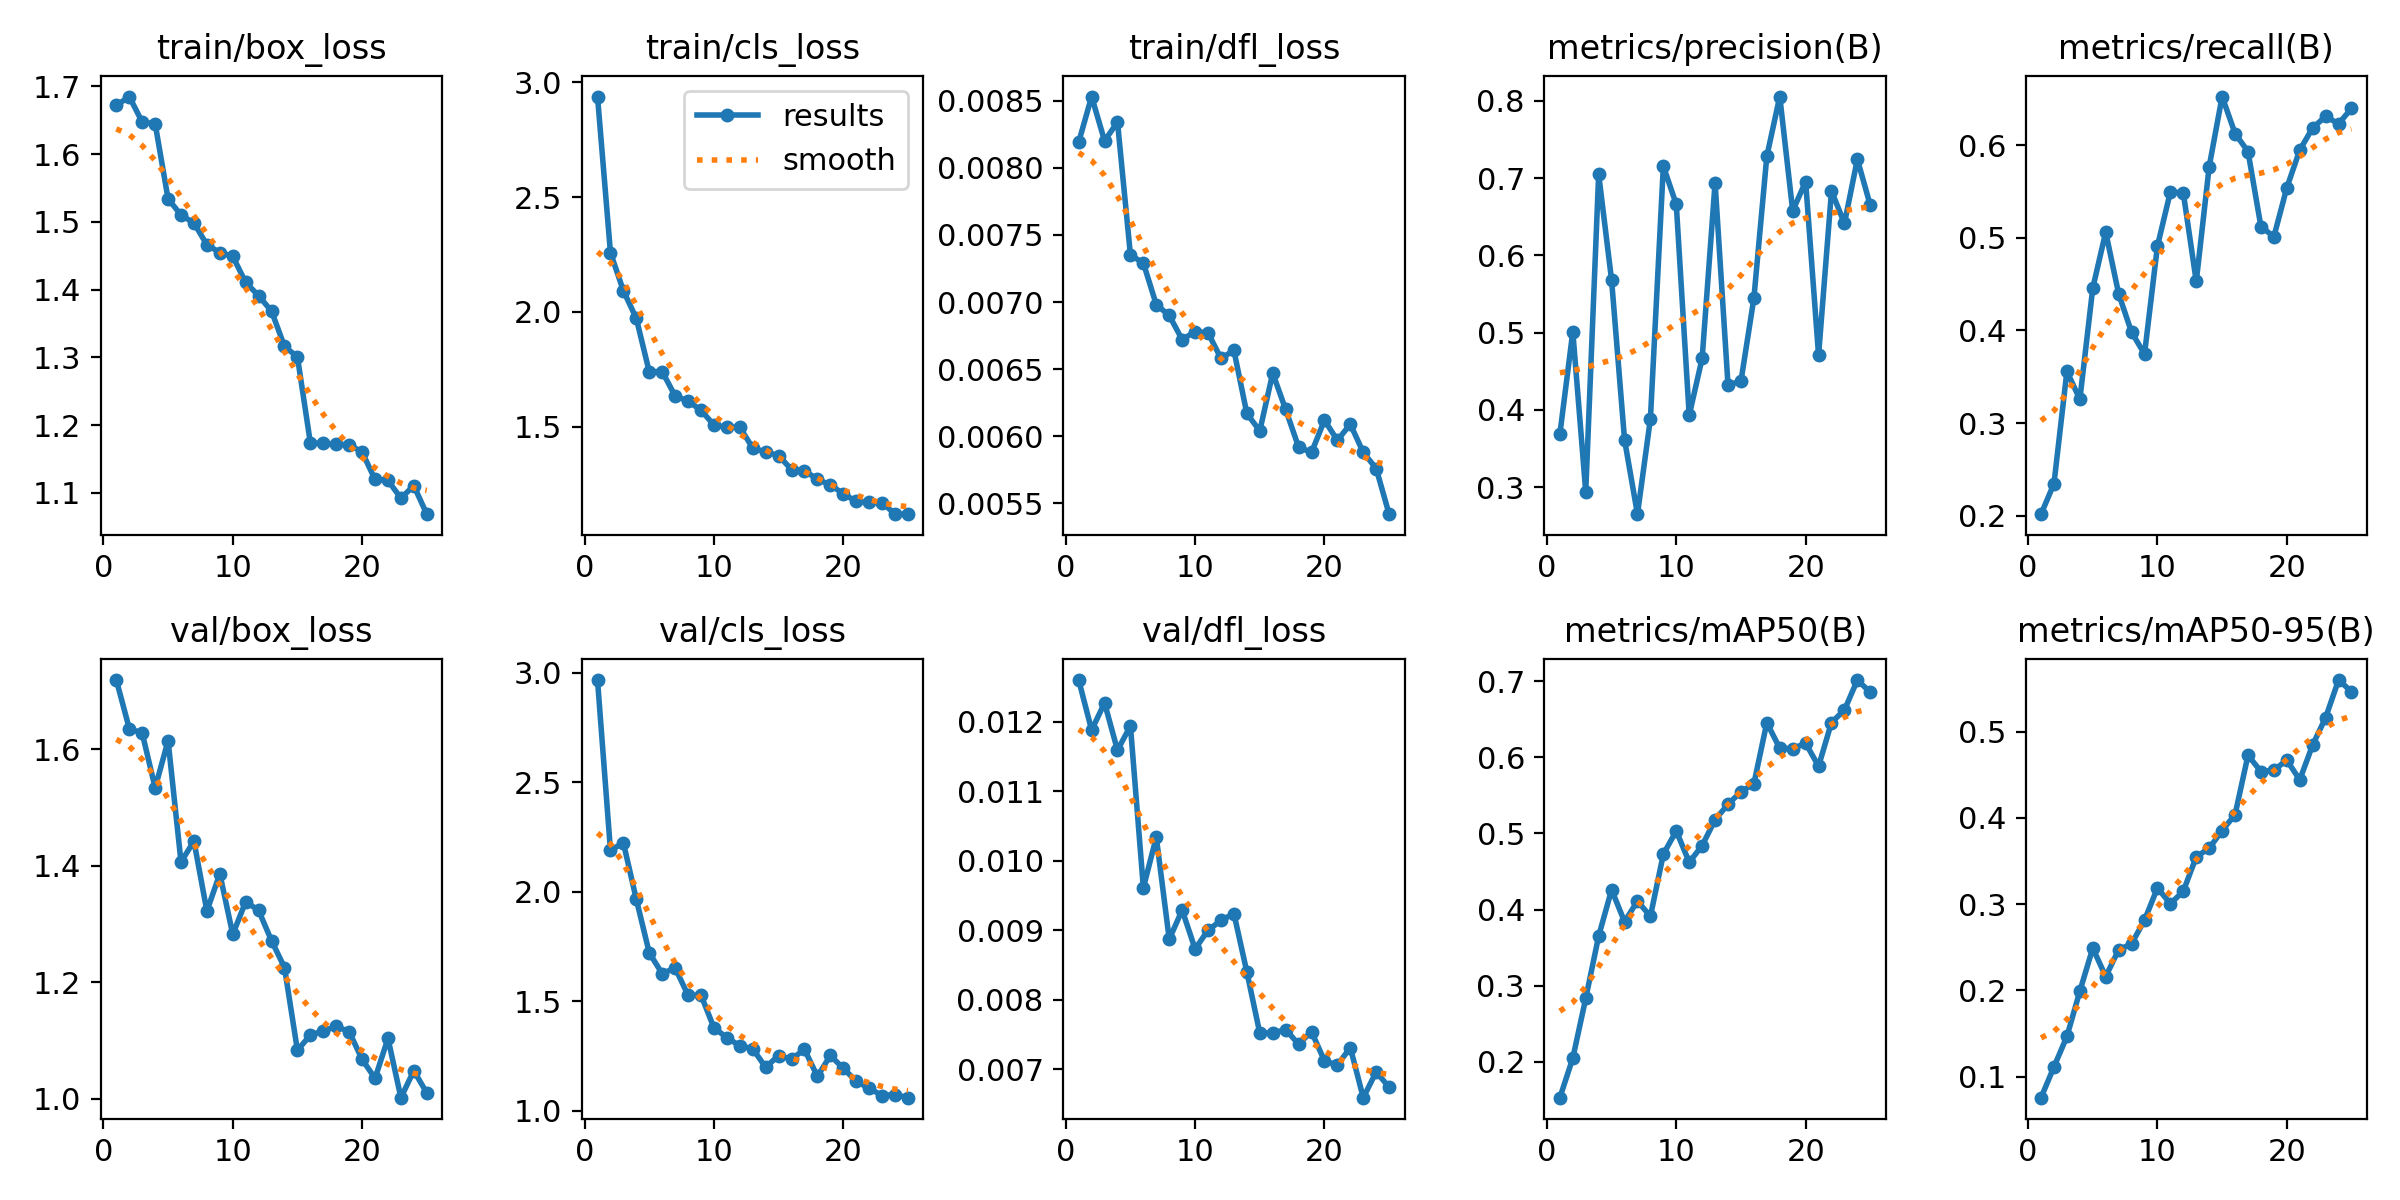

In [ ]:
# Monitor loss graphs for Model 1
show_results_plot('model1_adamw')

In [ ]:
# ── MODEL 2: SGD | 30 Epochs | Batch 20 | LR 0.001 ──────────────────────────
model2 = YOLO('yolo26n.pt')

results2 = model2.train(
    data=YAML_PATH,
    epochs=30,
    imgsz=640,
    optimizer='SGD',
    batch=20,
    lr0=0.001,
    name='model2_sgd'
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/sa1_v3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model2_sgd, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=

📊 Training curves — model2_sgd


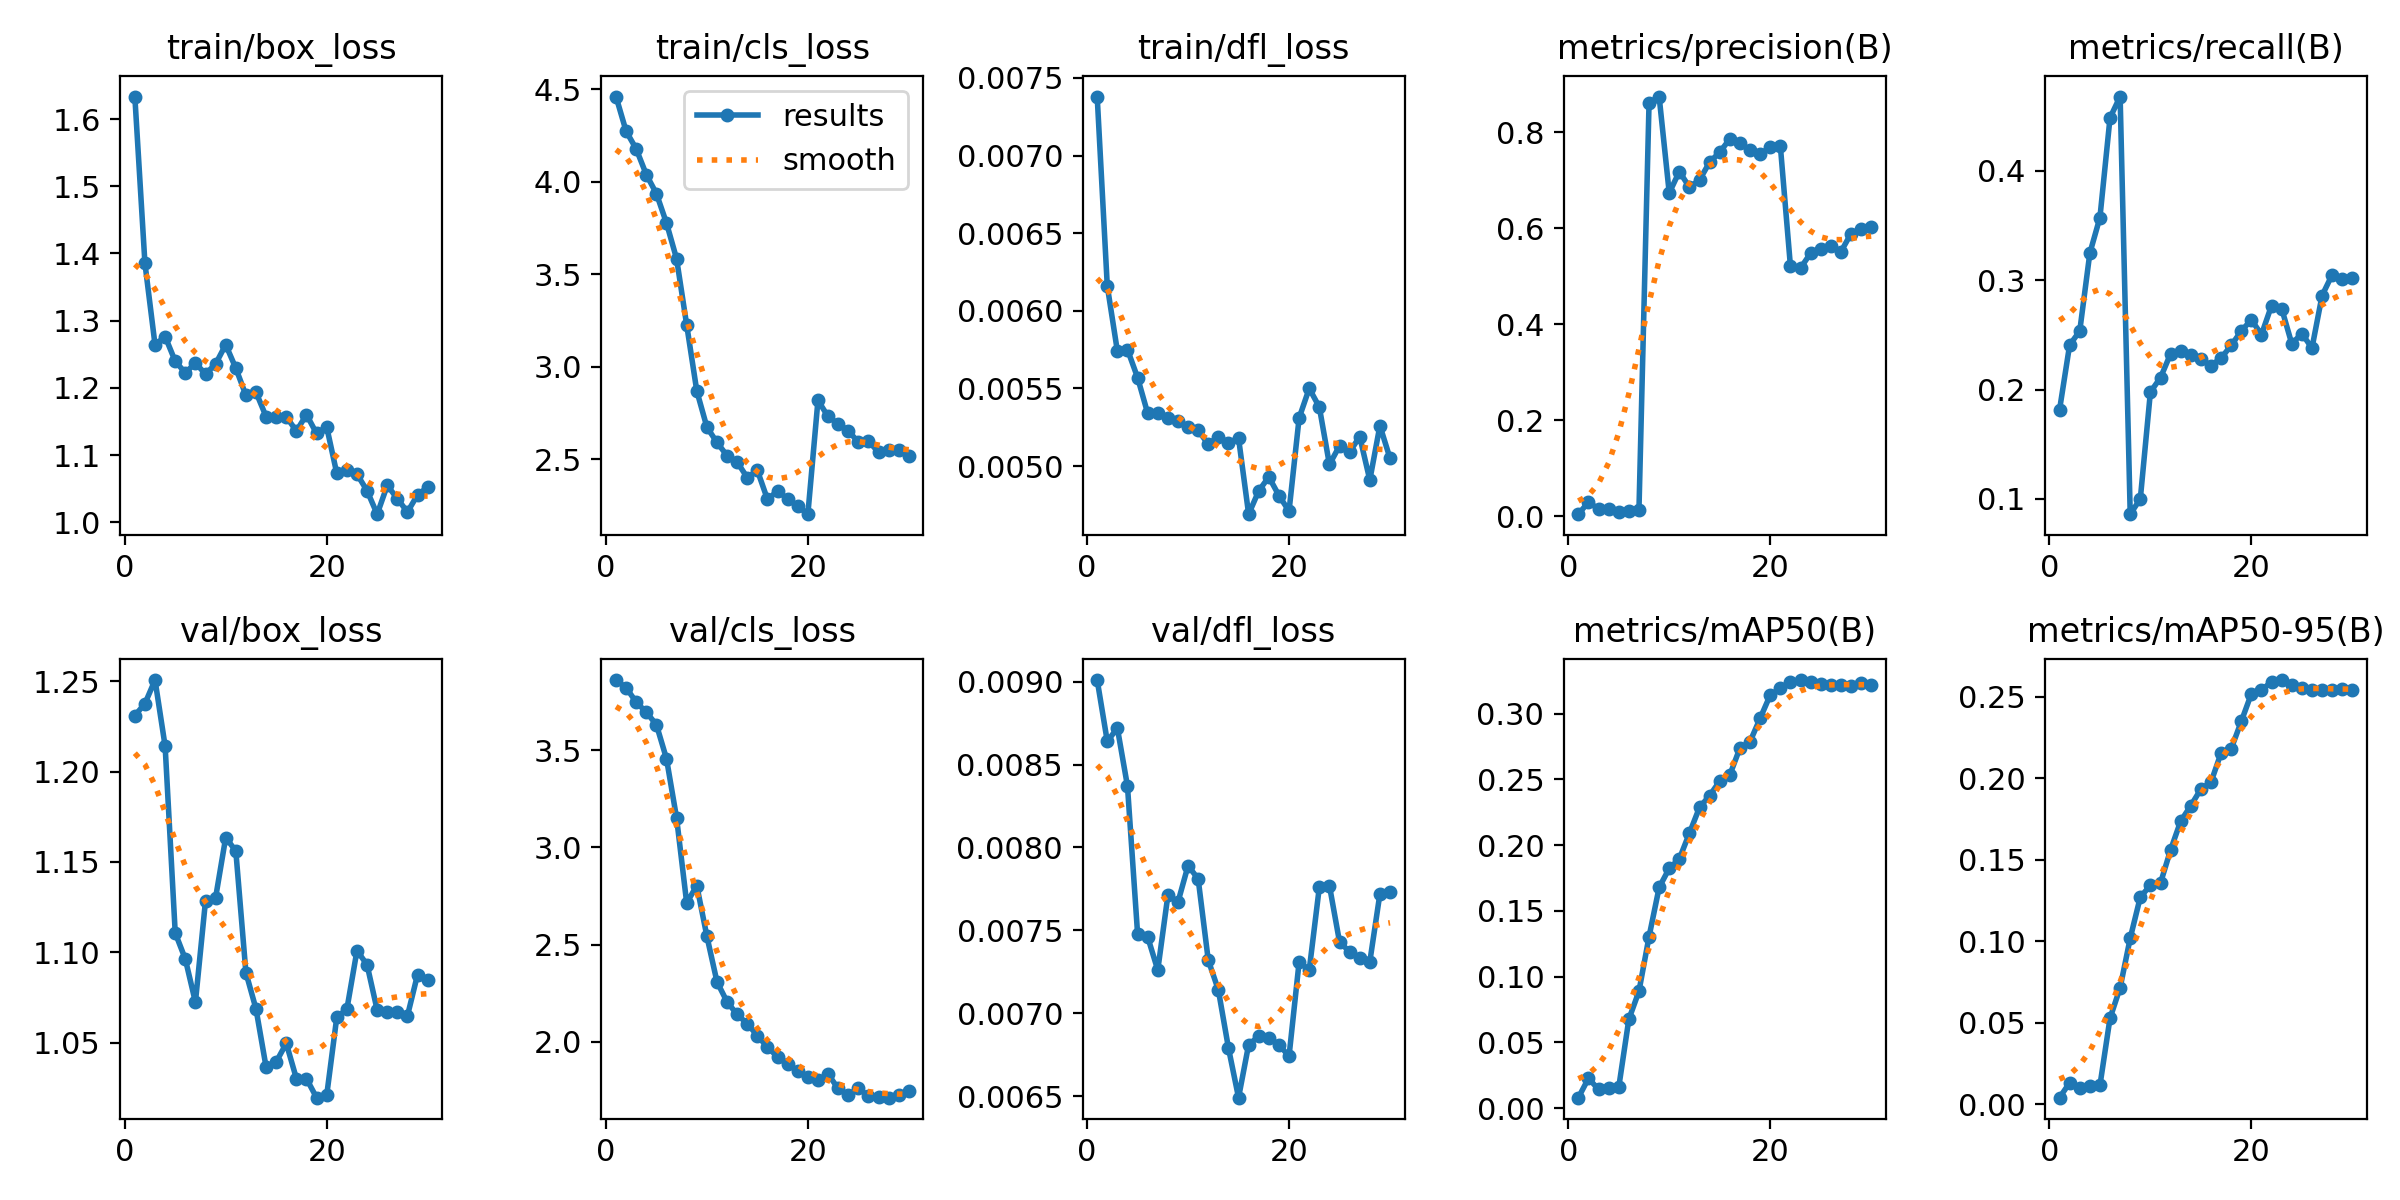

In [ ]:
show_results_plot('model2_sgd')

In [ ]:
# ── MODEL 3: auto | 40 Epochs | Batch -1 (AutoBatch) | LR 0.0001 ─────────────
model3 = YOLO('yolo26n.pt')

results3 = model3.train(
    data=YAML_PATH,
    epochs=40,
    imgsz=640,
    optimizer='auto',
    batch=-1,
    lr0=0.0001,
    name='model3_auto'
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/traffic_dataset/sa1_v3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model3_auto, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

📊 Training curves — model3_auto


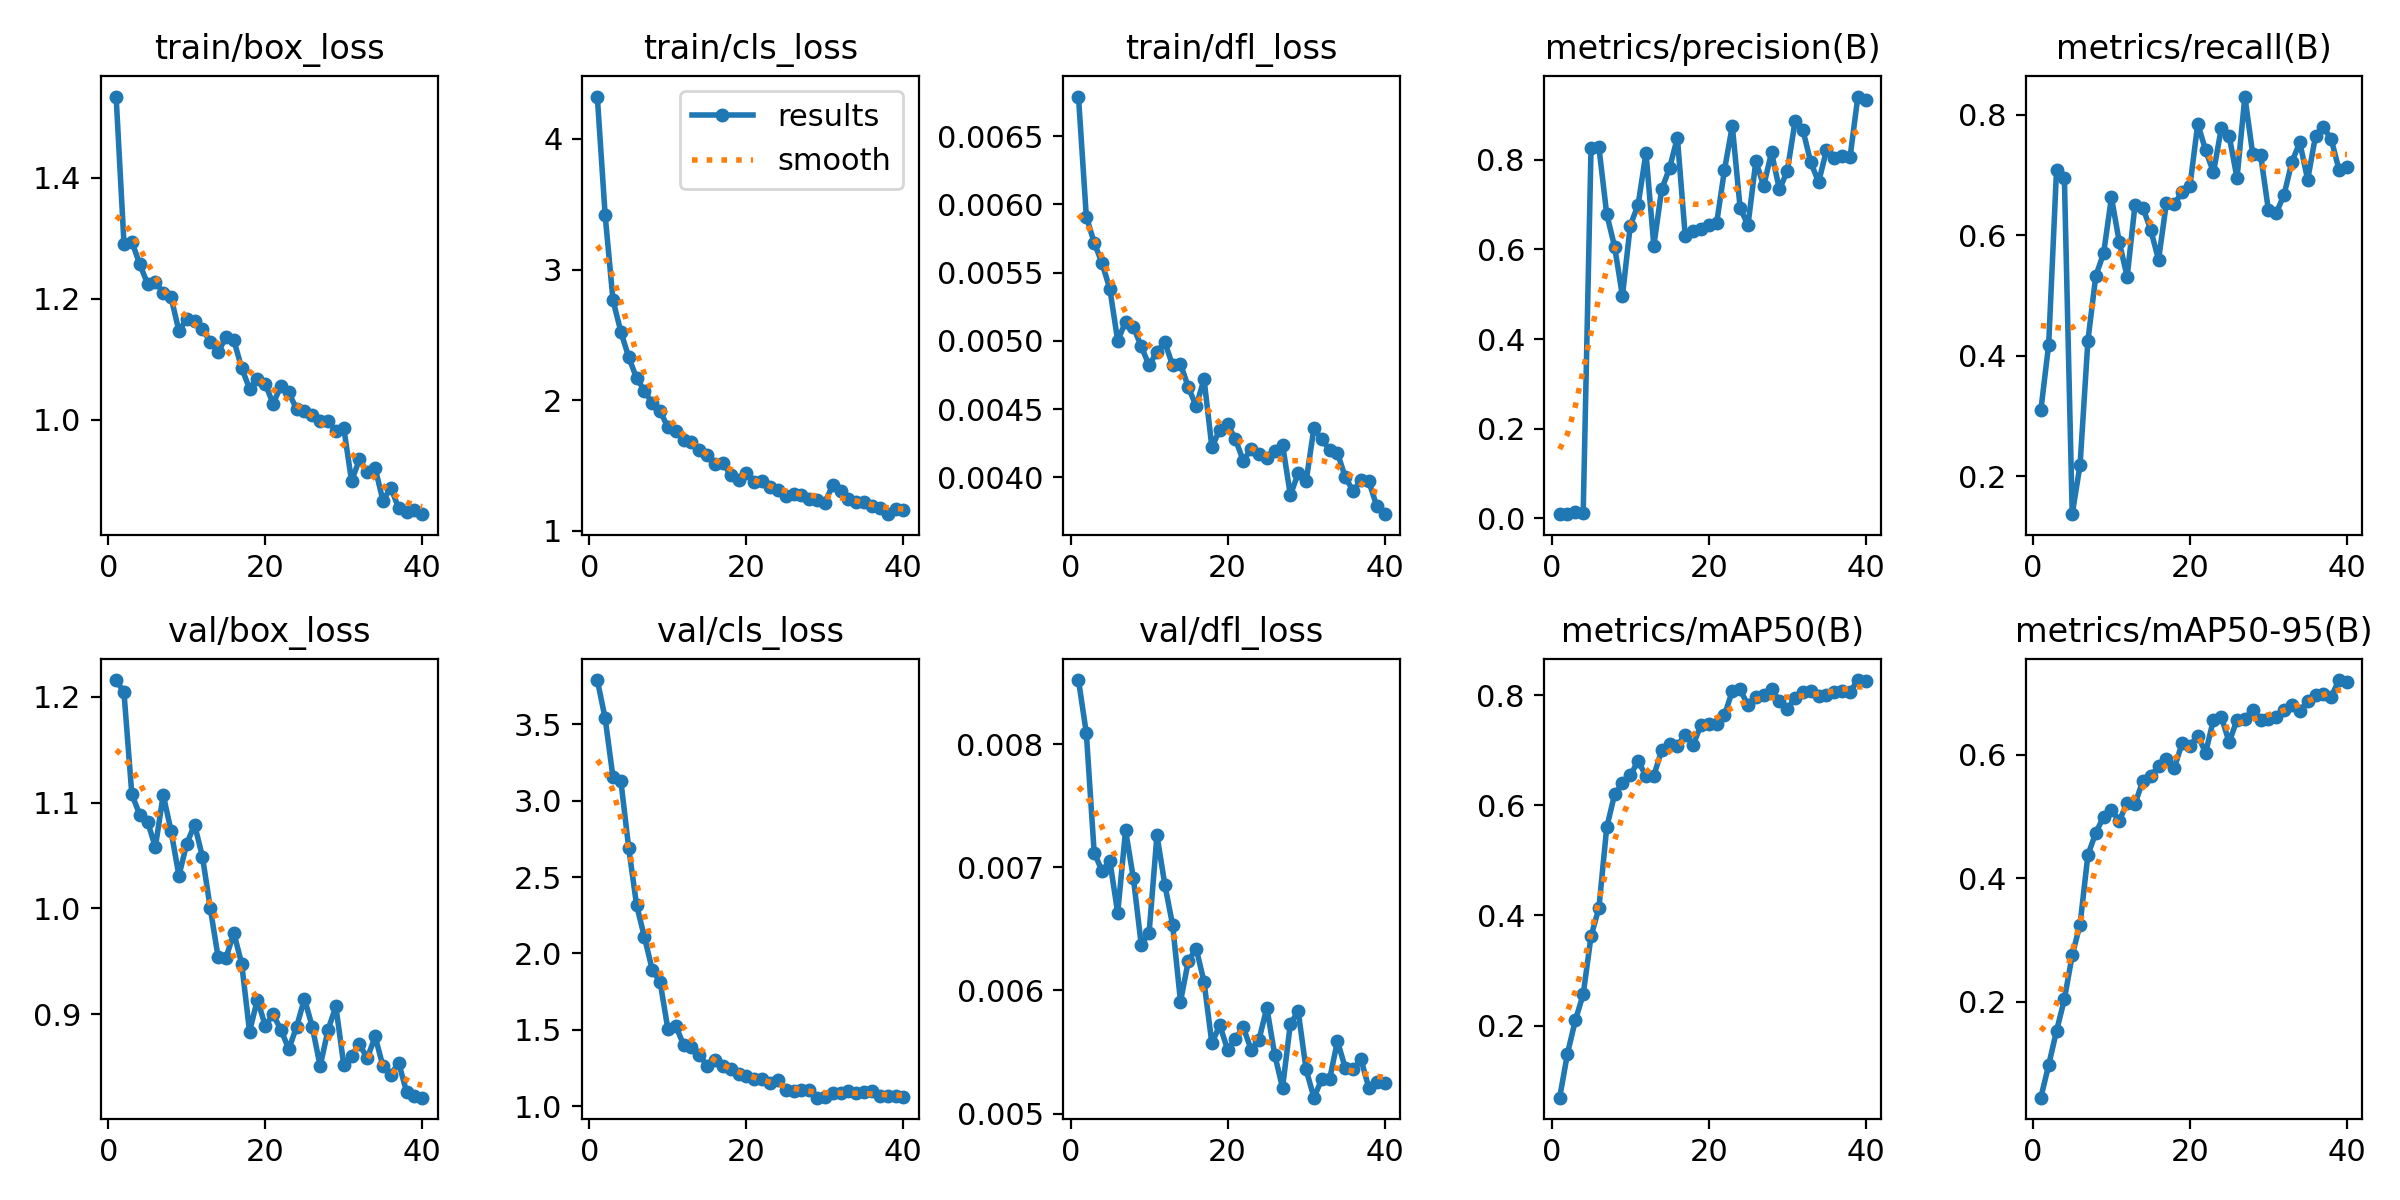

In [ ]:
show_results_plot('model3_auto')

---
## Part 3 — Model Evaluation: Confusion Matrix

YOLO saves `confusion_matrix.png` inside `runs/detect/<train_name>/`.

**How to read:**
- **Diagonal** = True Positives per class (higher = better detection for that class)
- **Off-diagonal** = Misclassifications between vehicle types (e.g. Motorcycle predicted as Car)
- **Background column** = False Positives — model detecting vehicles in empty/background areas

> **Key question:** Which vehicle class has the lowest diagonal value? That is the class each model struggled with most.


In [ ]:
# Display confusion matrices for all 3 models
# Uses glob to handle Ultralytics appending numbers to folder names (e.g. model1_adamw2)

def show_confusion_matrix(model_name, label):
    candidates = glob.glob(f'/content/runs/detect/{model_name}*/confusion_matrix.png')
    if candidates:
        print(f'\n=== Confusion Matrix — {label} ===')
        display(Image(candidates[0]))
        return candidates[0]
    else:
        print(f'[!] confusion_matrix.png not found for {model_name}')
        print(f'    Available folders: {glob.glob("/content/runs/detect/*/")}')
        return None

### Confusion Matrix for Model 1


=== Confusion Matrix — Model 1 — AdamW, 25 Epochs ===


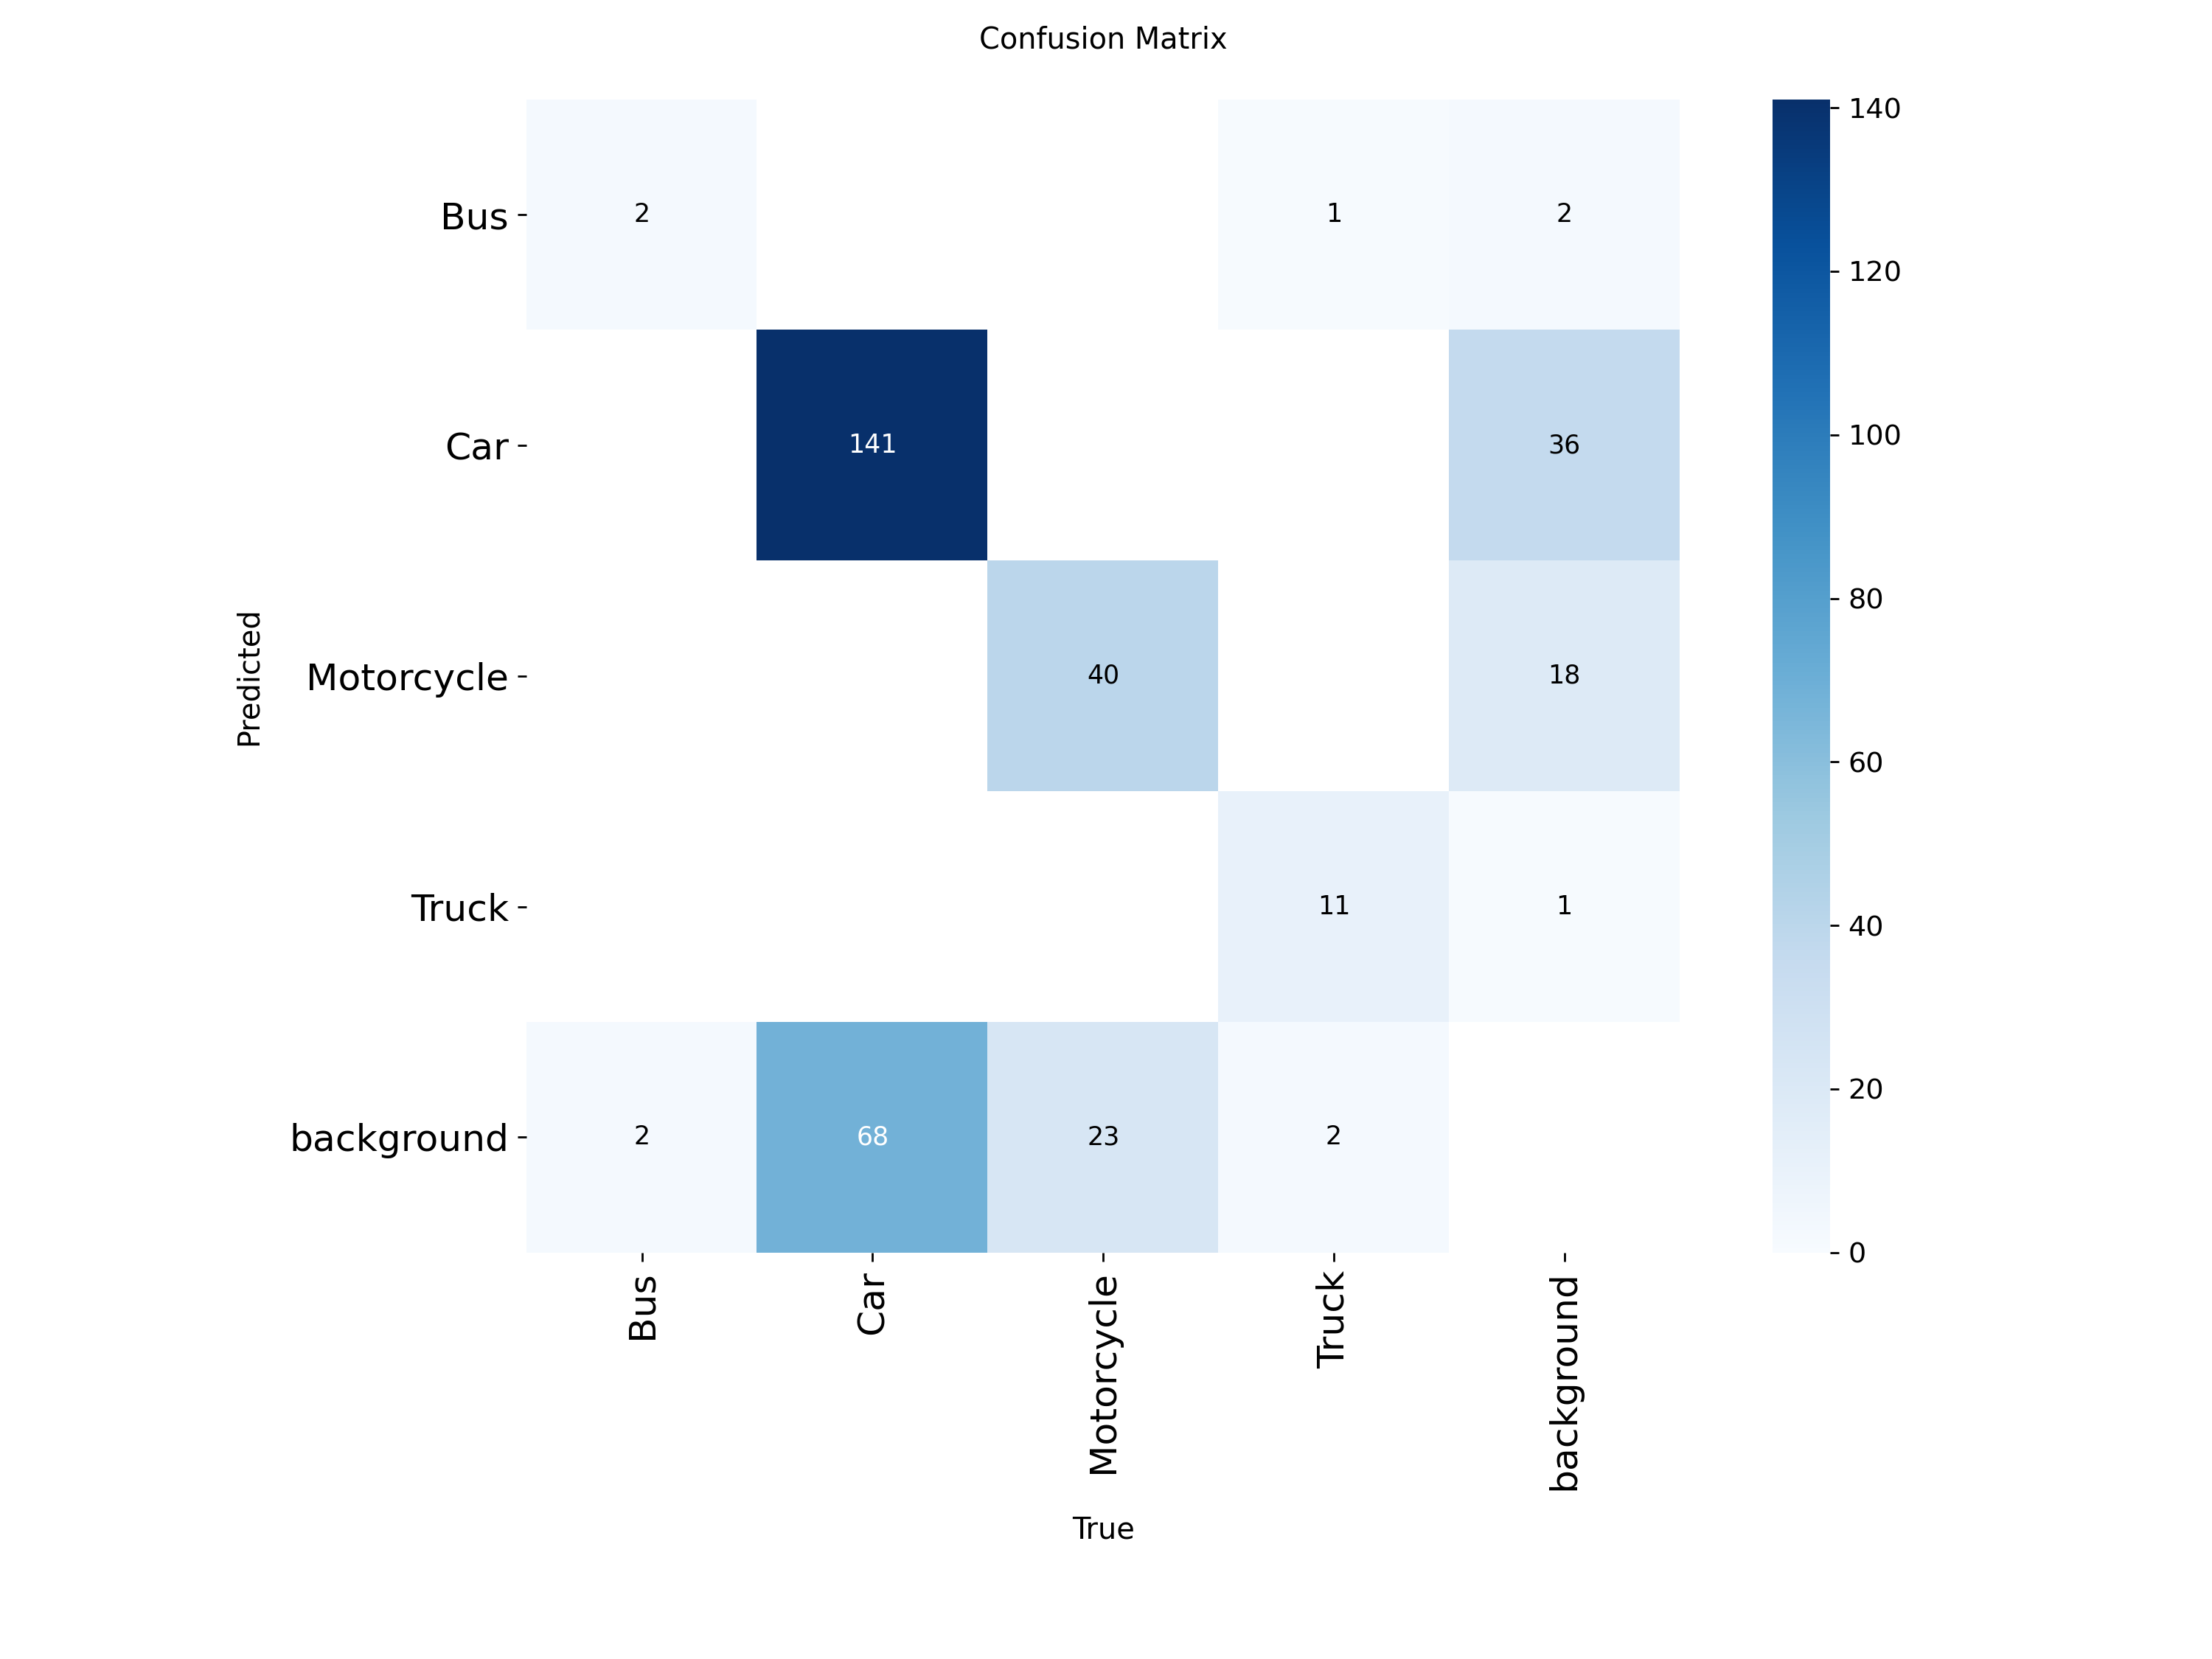

In [ ]:
cm1 = show_confusion_matrix('model1_adamw', 'Model 1 — AdamW, 25 Epochs')

### Confusion Matrix for Model 2


=== Confusion Matrix — Model 2 — SGD, 30 Epochs ===


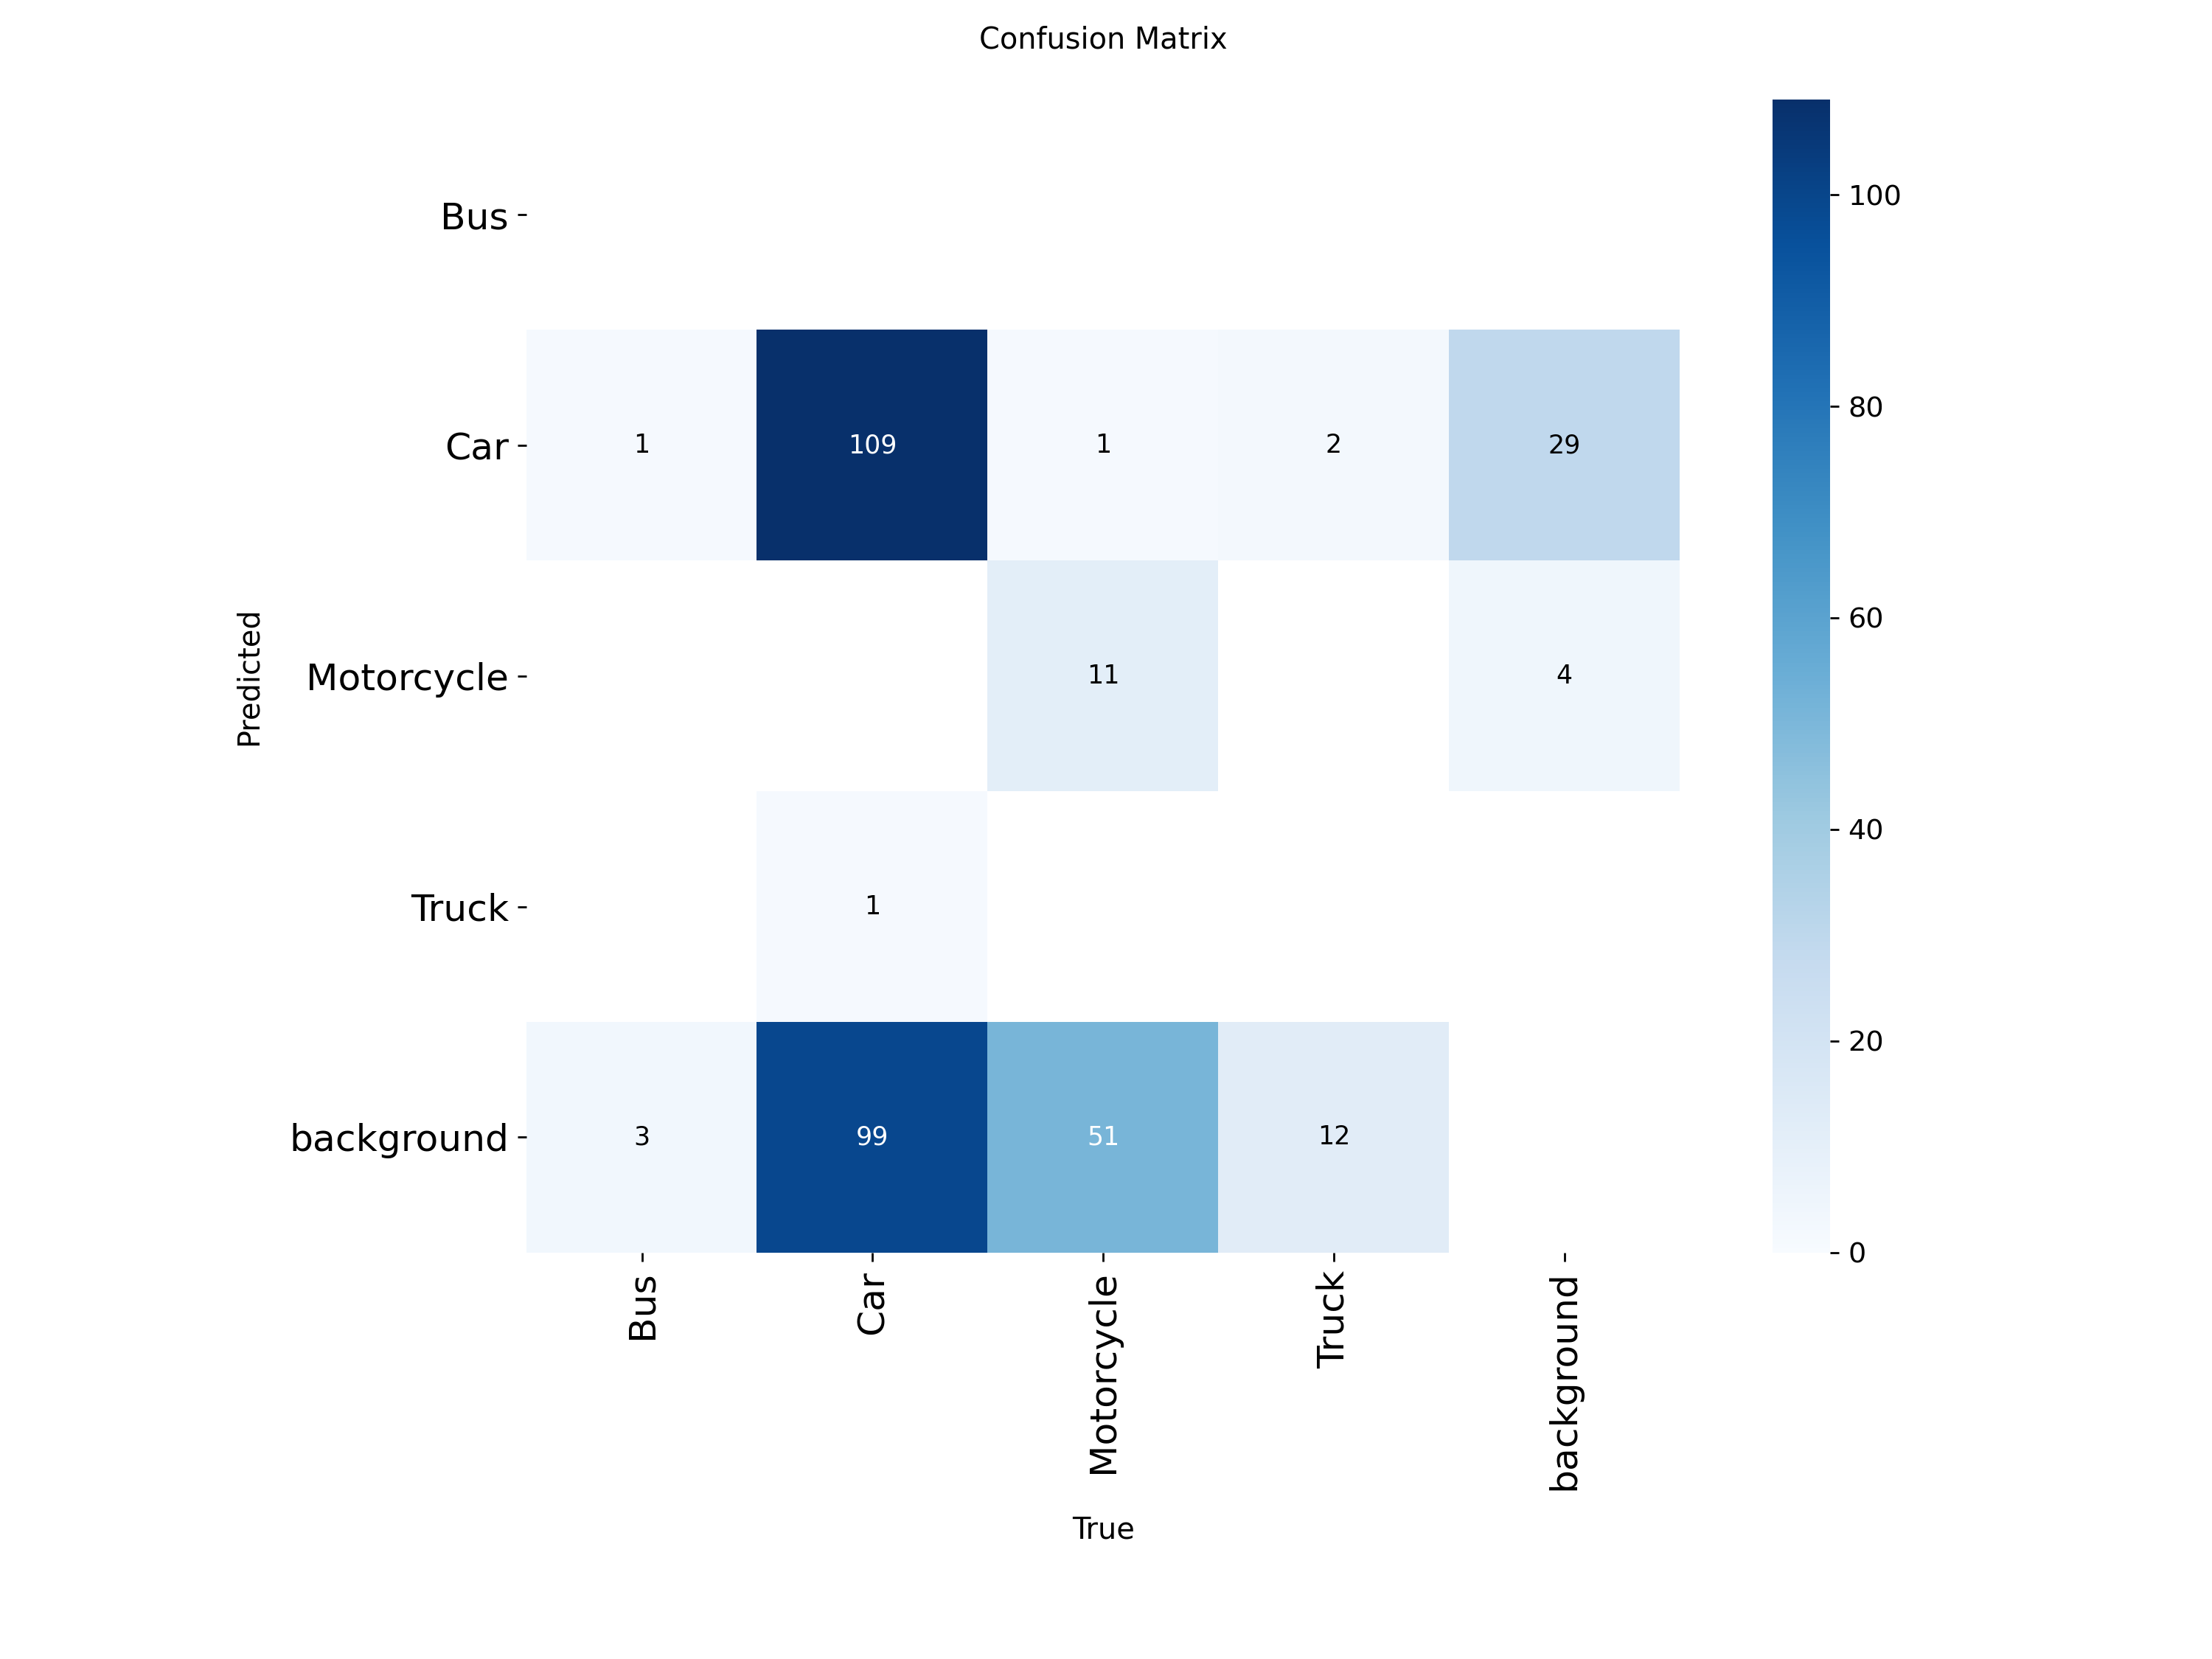

In [ ]:
cm2 = show_confusion_matrix('model2_sgd',   'Model 2 — SGD, 30 Epochs')

### Confusion Matrix for Model 3


=== Confusion Matrix — Model 3 — auto, 40 Epochs ===


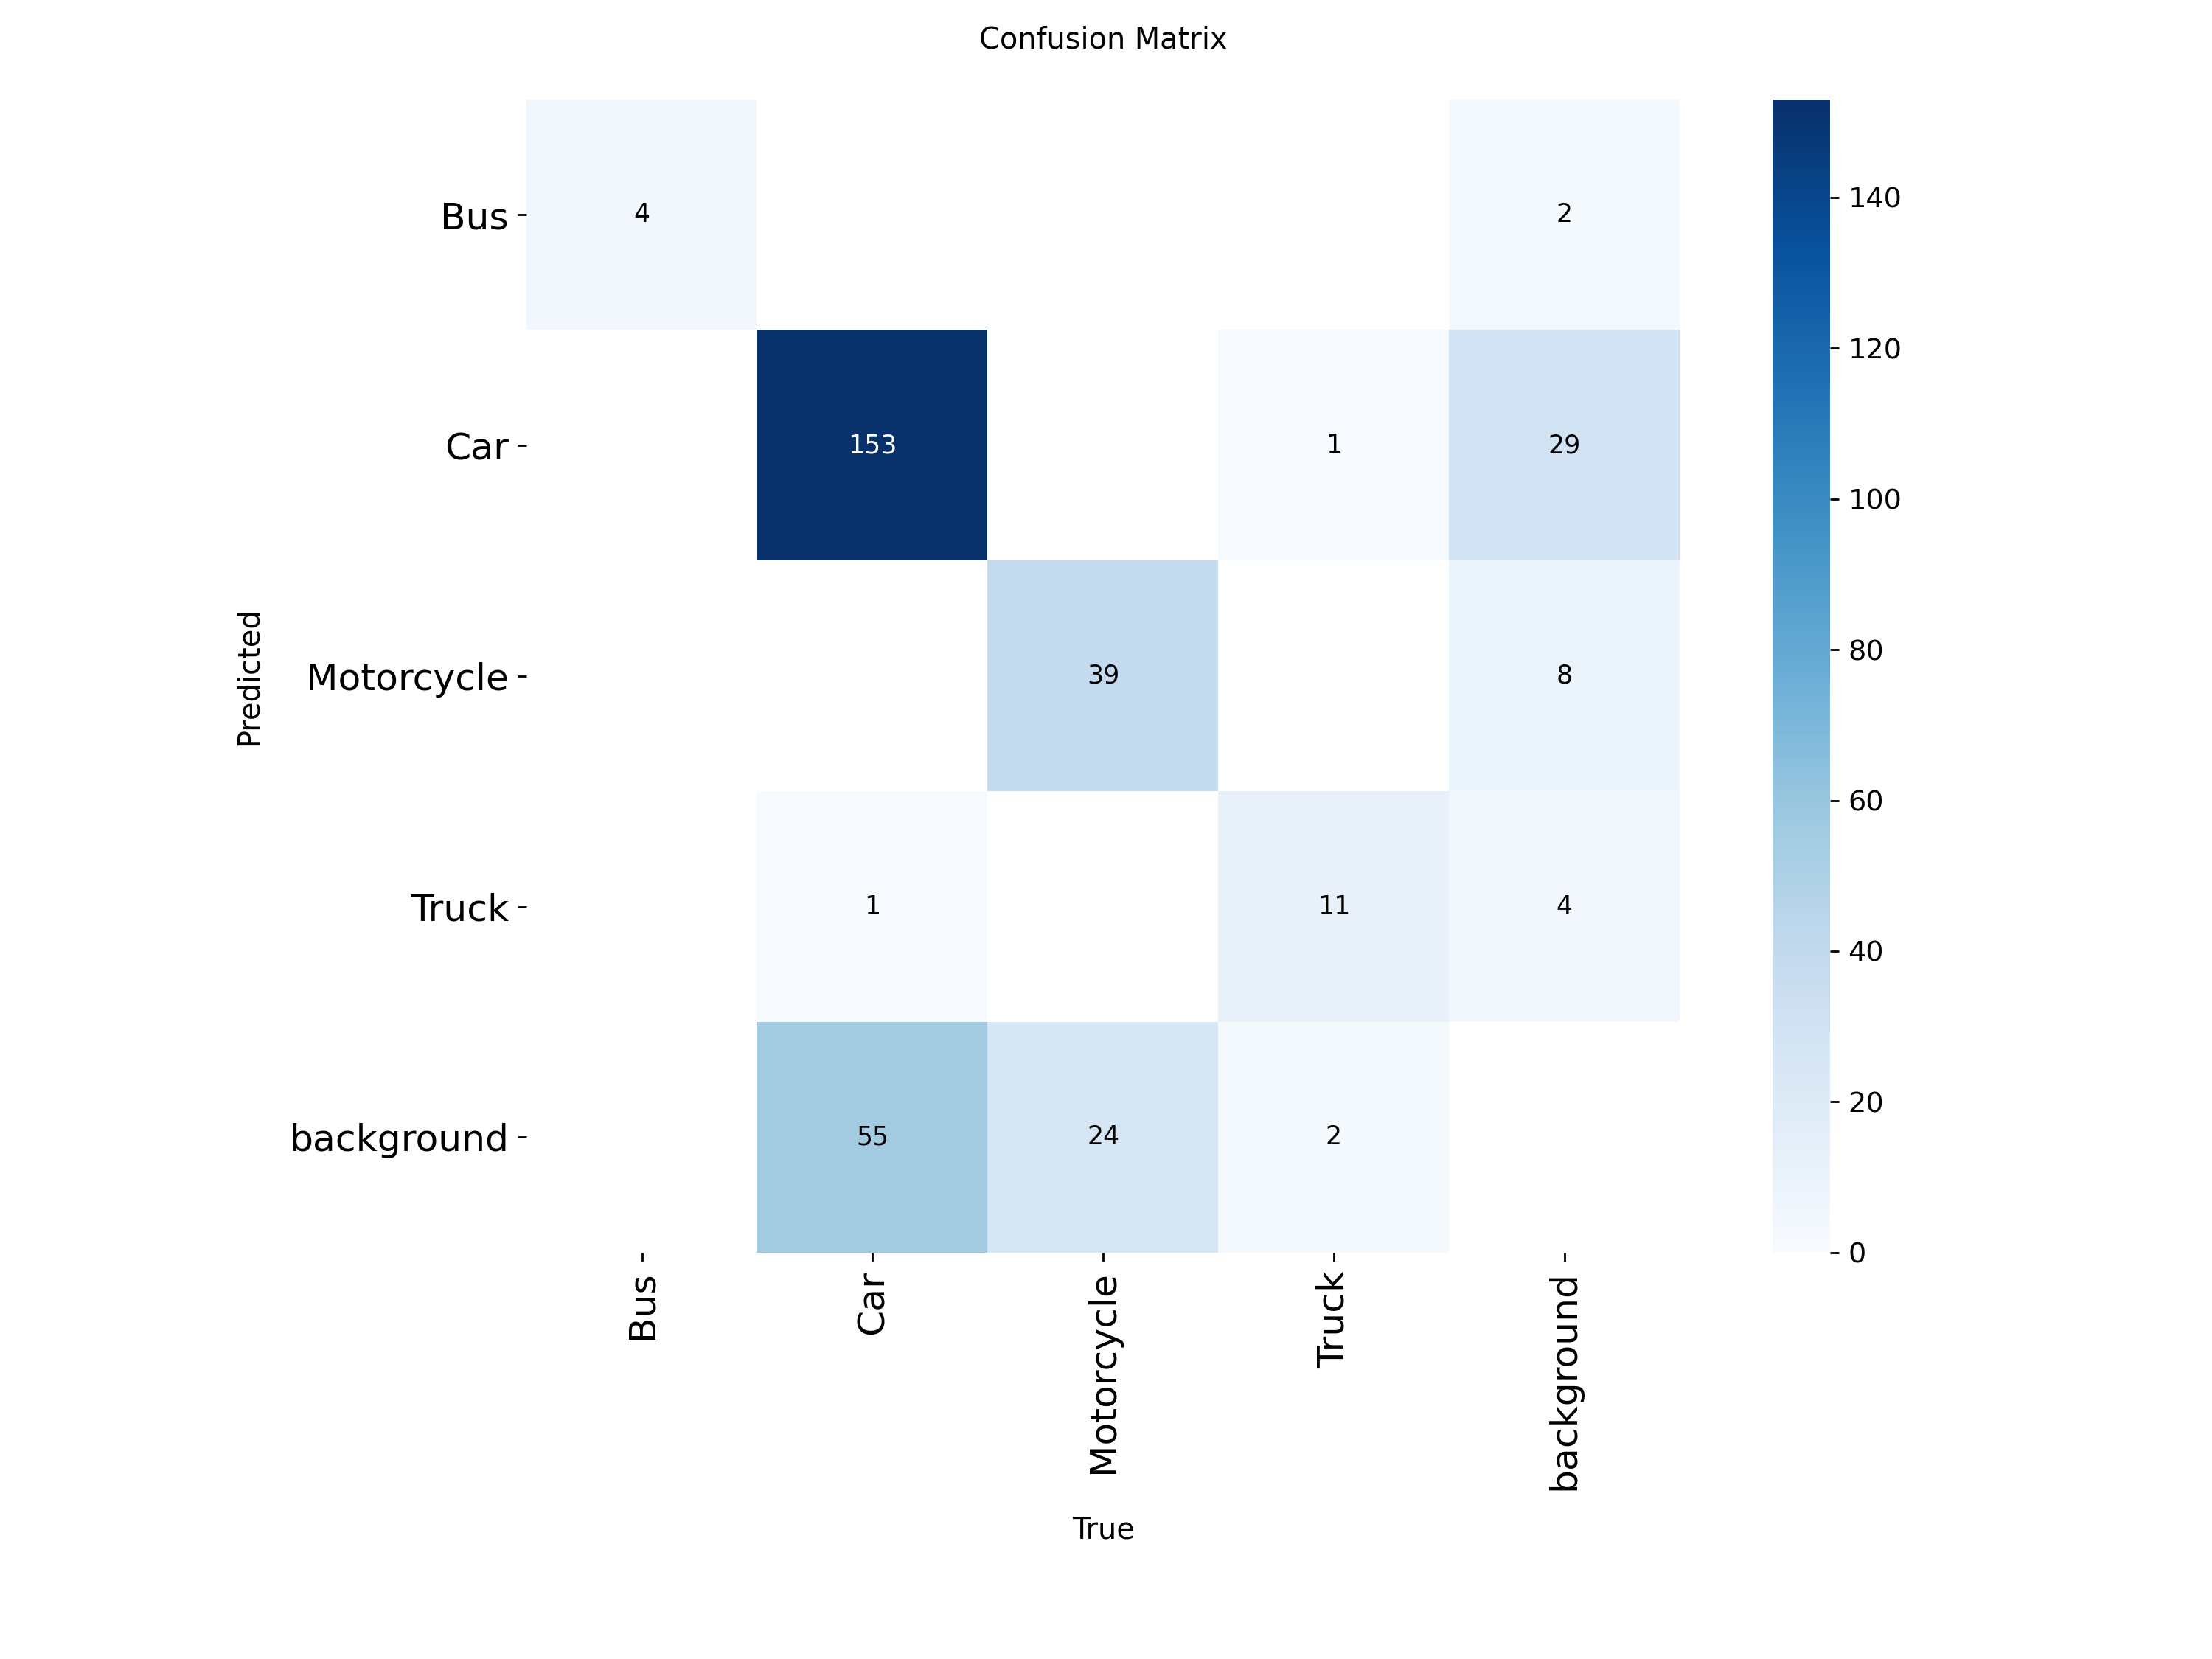

In [ ]:
cm3 = show_confusion_matrix('model3_auto',  'Model 3 — auto, 40 Epochs')

---
## Part 4 — Generating the Performance Table

Run `model.val()` to extract the final weights' performance, then generate summary tables using Pandas.


In [ ]:
# Run validation module on all 3 models
print('Validating Model 1...')
metrics1 = model1.val()

print('\nValidating Model 2...')
metrics2 = model2.val()

print('\nValidating Model 3...')
metrics3 = model3.val()

Validating Model 1...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.9±1.0 ms, read: 9.6±9.5 MB/s, size: 33.1 KB)
val: Scanning /content/drive/MyDrive/traffic_dataset/sa1_v3/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 12.6Mit/s 0.0s
val: /content/drive/MyDrive/traffic_dataset/sa1_v3/valid/images/frame_00101_jpg.rf.1653ff7eac0a087ec3fb26abaeea4589.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/traffic_dataset/sa1_v3/valid/images/frame_00122_jpg.rf.db1cf1ac448c50b56467545235b3fecf.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/traffic_dataset/sa1_v3/valid/images/frame_00232_jpg.rf.93c1c2acdee02b1a1450692d60bd6fd0.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/traffic_dataset/sa1_v3/valid/images/frame_00249_jpg.rf.60251383c6b9ed135f91c6ebf422191e.jpg: 1 duplicat

In [ ]:
import pandas as pd

# ── TABLE 1: Hyperparameter Settings (Pandas) ────────────────────────────────
hyper_df = pd.DataFrame({
    'Model'        : ['Model 1', 'Model 2', 'Model 3'],
    'Epochs'       : [25, 30, 40],
    'Image Size'   : [640, 640, 640],
    'Optimizer'    : ['AdamW', 'SGD', 'auto'],
    'Batch Size'   : [4, 20, -1],
    'Learning Rate': [0.01, 0.001, 0.0001]
})

print('=== TABLE 1: Hyperparameter Configuration ===')
display(hyper_df)

=== TABLE 1: Hyperparameter Configuration ===


,Model,Epochs,Image Size,Optimizer,Batch Size,Learning Rate
0,Model 1,25,640,AdamW,4,0.0100
1,Model 2,30,640,SGD,20,0.0010
2,Model 3,40,640,auto,-1,0.0001


In [ ]:
# ── TABLE 2: Performance Metrics — mAP50, Precision, Recall, F1 (Pandas) ────

def extract_metrics(m):
    """Safely extract metrics. Handles different Ultralytics attribute paths."""
    try:
        map50     = round(float(m.box.map50), 4)
        precision = round(float(m.box.mp),    4)
        recall    = round(float(m.box.mr),    4)
    except AttributeError:
        rd        = m.results_dict
        map50     = round(rd.get('metrics/mAP50(B)', 0.0),     4)
        precision = round(rd.get('metrics/precision(B)', 0.0), 4)
        recall    = round(rd.get('metrics/recall(B)', 0.0),    4)
    f1 = round(2 * precision * recall / (precision + recall), 4) if (precision + recall) > 0 else 0.0
    return map50, precision, recall, f1

v = [extract_metrics(m) for m in [metrics1, metrics2, metrics3]]

metrics_df = pd.DataFrame({
    'Model'    : ['Model 1 (AdamW)', 'Model 2 (SGD)', 'Model 3 (auto)'],
    'mAP50'    : [v[0][0], v[1][0], v[2][0]],
    'Precision': [v[0][1], v[1][1], v[2][1]],
    'Recall'   : [v[0][2], v[1][2], v[2][2]],
    'F1 Score' : [v[0][3], v[1][3], v[2][3]]
})

print('=== TABLE 2: Model Performance Metrics ===')
display(metrics_df)

=== TABLE 2: Model Performance Metrics ===


,Model,mAP50,Precision,Recall,F1 Score
0,Model 1 (AdamW),0.7015,0.7251,0.6219,0.6695
1,Model 2 (SGD),0.3254,0.5170,0.2742,0.3583
2,Model 3 (auto),0.8271,0.9414,0.7091,0.8089


In [ ]:
# ── TABLE 3: Per-Class AP50 — Car, Motorcycle, Bus, Truck ───────────────────

CLASS_NAMES = ['Car', 'Motorcycle', 'Bus', 'Truck']

def extract_per_class(m, class_names):
    try:
        ap50_vals = m.box.ap50
        return {c: round(float(ap50_vals[i]), 4) for i, c in enumerate(class_names)}
    except Exception:
        try:
            ap50_vals = m.ap50
            return {c: round(float(ap50_vals[i]), 4) for i, c in enumerate(class_names)}
        except Exception:
            return {c: None for c in class_names}

pc = [extract_per_class(m, CLASS_NAMES) for m in [metrics1, metrics2, metrics3]]

per_class_df = pd.DataFrame({
    'Class'        : CLASS_NAMES,
    'Model 1 AP50' : [pc[0][c] for c in CLASS_NAMES],
    'Model 2 AP50' : [pc[1][c] for c in CLASS_NAMES],
    'Model 3 AP50' : [pc[2][c] for c in CLASS_NAMES],
})

print('=== TABLE 3: Per-Class AP50 — Car, Motorcycle, Bus, Truck ===')
print('(Lower value = class the model struggled with most)')
display(per_class_df)

=== TABLE 3: Per-Class AP50 — Car, Motorcycle, Bus, Truck ===
(Lower value = class the model struggled with most)


,Class,Model 1 AP50,Model 2 AP50,Model 3 AP50
0,Car,0.6456,0.0622,0.9950
1,Motorcycle,0.7433,0.6239,0.8000
2,Bus,0.6147,0.3932,0.6786
3,Truck,0.8024,0.2224,0.8349


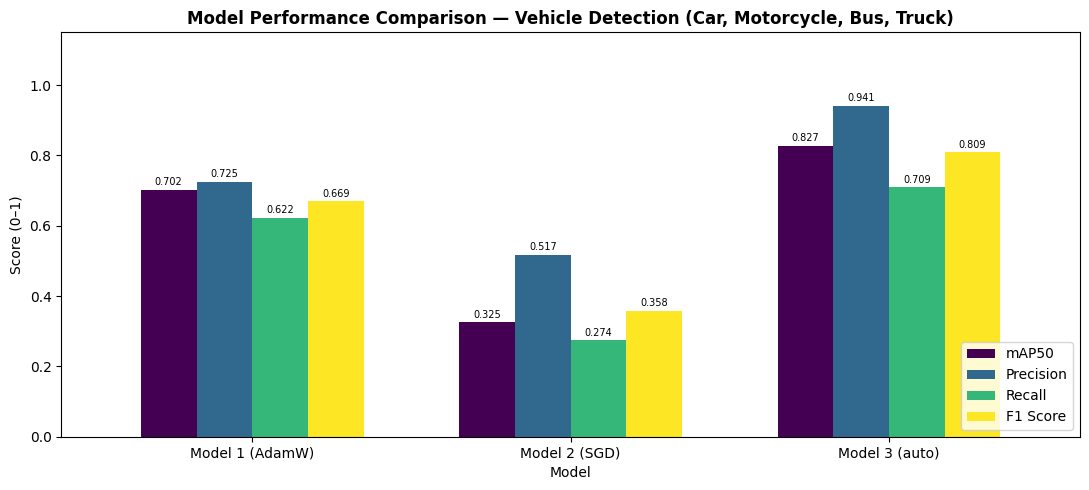

In [ ]:
# ── Bar Chart: Visual Metric Comparison ─────────────────────────────────────
import matplotlib.pyplot as plt
import pathlib

PROJECT_DIR     = pathlib.Path('/content/drive/MyDrive/YOLOv26_Project')
SCREENSHOTS_DIR = PROJECT_DIR / 'Screenshots'
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

ax = metrics_df.set_index('Model')[['mAP50','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(11, 5), rot=0, width=0.7, colormap='viridis'
)
ax.set_title('Model Performance Comparison — Vehicle Detection (Car, Motorcycle, Bus, Truck)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(SCREENSHOTS_DIR / 'metrics_comparison.png', dpi=150)
plt.show()

---
## Part 5 — Save All Outputs to Google Drive


In [ ]:
import shutil

# Copy training runs folder (contains confusion matrices, best weights, graphs)
RUNS_DEST = PROJECT_DIR / 'runs'
if os.path.exists('/content/runs'):
    shutil.copytree('/content/runs', RUNS_DEST, dirs_exist_ok=True)
    print('✅ runs/ folder copied to Drive')
else:
    print('[!] /content/runs not found — ensure all 3 models finished training')

# Save all tables to CSV
hyper_df.to_csv(PROJECT_DIR     / 'hyperparameters.csv',  index=False)
metrics_df.to_csv(PROJECT_DIR   / 'metrics_results.csv',  index=False)
per_class_df.to_csv(PROJECT_DIR / 'per_class_metrics.csv',index=False)
print('✅ CSV tables saved to Drive')

print(f'\n📁 Project saved at: {PROJECT_DIR}')

✅ runs/ folder copied to Drive
✅ CSV tables saved to Drive

📁 Project saved at: /content/drive/MyDrive/YOLOv26_Project


In [62]:
gitignore_content = """
# Google Docs/Sheets/Slides (not uploadable to git)
*.gdoc
*.gsheet
*.gslides
*.gform

# Large files
*.pt
*.zip
*.mp4
runs/
frames_*/
augmented/
processed/

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/
"""

with open('/content/drive/MyDrive/YOLOv26_Project/.gitignore', 'w') as f:
    f.write(gitignore_content)

print('✅ .gitignore updated')

✅ .gitignore updated


In [68]:
import os

# ── Configure your Git identity ────────────────────────────
GITHUB_USERNAME = 'edelle-del'       # ✏️ change this
GITHUB_EMAIL    = 'egmlumabi@mymail.mapua.edu.ph'      # ✏️ change this
REPO_NAME       = 'SA2_GROUP18'  # ✏️ change this
# TOKEN REMOVED FOR SECURITY

os.chdir('/content/drive/MyDrive/YOLOv26_Project')

# Write .gitignore
with open('.gitignore', 'w') as f:
    f.write("*.gdoc\n*.gsheet\n*.gslides\n*.gform\n*.pt\n*.zip\n*.mp4\nruns/\nframes_*/\naugmented/\nprocessed/\n__pycache__/\n*.pyc\n.ipynb_checkpoints/\n")

print('✅ .gitignore written')

✅ .gitignore written


In [73]:
%%bash
cd /content/drive/MyDrive/YOLOv26_Project

git remote remove origin 2>/dev/null || true
# TOKEN REMOVED FOR SECURITY

git push -u origin main --force

Branch 'main' set up to track remote branch 'main' from 'origin'.


To https://github.com/edelle-del/SA2_GROUP18.git
 + ad5a4ee...5473460 main -> main (forced update)


In [75]:
import os
result = os.popen('find /content/drive -name "*.ipynb" 2>/dev/null').read()
print(result)

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Module 2 Notebook Format.ipynb
/content/drive/MyDrive/Colab Notebooks/CSS145 BM3 GROUP 4 ACT4.ipynb
/content/drive/MyDrive/Colab Notebooks/BM3 GROUP 4 PROJECT PROPOSAL 2.ipynb
/content/drive/MyDrive/Colab Notebooks/CSS145 BM3 GROUP 4 ACT2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/FA6_Test_Script_Group18.ipynb
/content/drive/MyDrive/Colab Notebooks/SA2_GROUP18 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/SA1_GROUP18.ipynb
/content/drive/MyDrive/Colab Notebooks/SA2_GROUP18.ipynb



In [79]:
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
cp: missing destination file operand after '/content/drive/MyDrive/Colab Notebooks/SA2_GROUP18.ipynb'
Try 'cp --help' for more information.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote:
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote:
remote:     - Push cannot contain secrets
remote:
remote:
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:
remote:
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        locations:
remote:          - commit: 9e764fd156025f18a9f0be24aae42b6d52ce10a0
remote:            path: SA2_GROUP18.ipynb:1
remote:
remote:        (?) To push, remove secret from commit(s) or follow this URL to allow the secret.
remote:        https://github.com/edelle-del/SA2_GROUP18/security/secret-scanning/unblock-secret/3AIvhzv92ns6FU7TKuFqPc5mMSJ
remote:
remote:
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        locations:
remote:          - commit: 9e764fd156025f18a9f0be24aae42b6d52ce10a0
remote:            path: SA2_GROUP18.ipynb:1
remote:
remote:        (?) To push, remove secret from commit(s) or follow this URL to allow the secret.
remote:        https://github.com/edelle-del/SA2_GROUP18/security/secret-scanning/unblock-secret/3AIvhveBmag4SmKMuC9CtvND0zU
remote:
remote:
remote:
To https://github.com/edelle-del/SA2_GROUP18.git
 ! [remote rejected] main -> main (push declined due to repository rule violations)
error: failed to push some refs to 'https://github.com/edelle-del/SA2_GROUP18.git'
---------------------------------------------------------------------------
CalledProcessError                        Traceback (most recent call last)
/tmp/ipython-input-1904/3376261665.py in <cell line: 0>()
----> 1 get_ipython().run_cell_magic('bash', '', 'cp "/content/drive/MyDrive/Colab Notebooks/SA2_GROUP18.ipynb"\n\ncd /content/drive/MyDrive/YOLOv26_Project\ngit add SA2_GROUP18.ipynb\ngit commit -m "Add SA2 notebook"\ngit push origin main\n')

4 frames
<decorator-gen-103> in shebang(self, line, cell)

/usr/local/lib/python3.12/dist-packages/IPython/core/magics/script.py in shebang(self, line, cell)
    243             sys.stderr.flush()
    244         if args.raise_error and p.returncode!=0:
--> 245             raise CalledProcessError(p.returncode, cell, output=out, stderr=err)
    246
    247     def _run_script(self, p, cell, to_close):

CalledProcessError: Command 'b'cp "/content/drive/MyDrive/Colab Notebooks/SA2_GROUP18.ipynb"\n\ncd /content/drive/MyDrive/YOLOv26_Project\ngit add SA2_GROUP18.ipynb\ngit commit -m "Add SA2 notebook"\ngit push origin main\n'' returned non-zero exit status 1.

SyntaxError: invalid character '—' (U+2014) (4092245010.py, line 11)